In [191]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [192]:
# Data generate X,Y
def generateDataset(m):
  X = np.random.randn(m) * 10
  noise = np.random.randn(m)
  y = 3 * X + 1 + 5 * noise

  return X, y

In [193]:
X, y = generateDataset(100)
print(X.shape, y.shape)

(100,) (100,)


In [194]:
def plotData(X, y, color="orange", title="Data"):
  plt.title(title)
  plt.xlabel("X")
  plt.ylabel("Y")
  plt.scatter(X,y, c=color)
  plt.show()

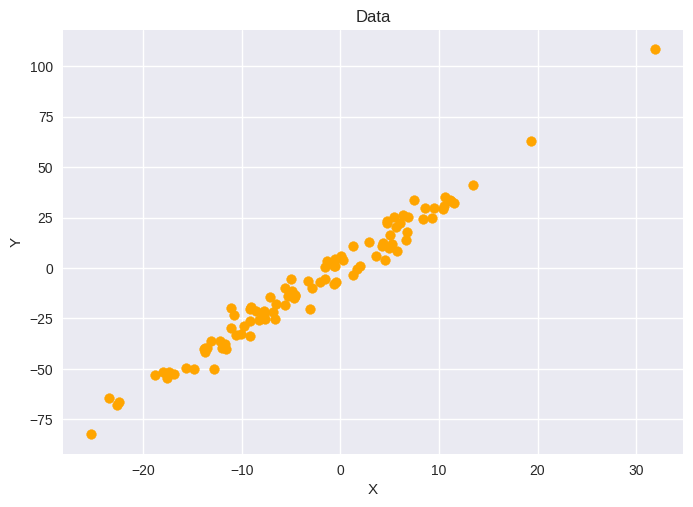

In [195]:
plotData(X, y)

In [196]:
def normaliseData(X):
  X = (X-X.mean())/X.std()
  return X

In [197]:
def trainTestSplit(X, y, split=0.8):
  m = X.shape[0]
  data = np.zeros((m, 2))

  data[:, 0] = X
  data[:, 1] = y

  np.random.shuffle(data)

  split = int(m*split)

  XTr = data[:split , 0]
  yTr = data[:split , 1]

  XTe = data[split: , 0]
  yTe = data[split: , 1]

  return XTr, yTr, XTe, yTe

In [198]:
XT, yT, Xt, yt = trainTestSplit(X, y)

In [199]:
print(XT.shape, yT.shape)
print(Xt.shape, yt.shape)

(80,) (80,)
(20,) (20,)


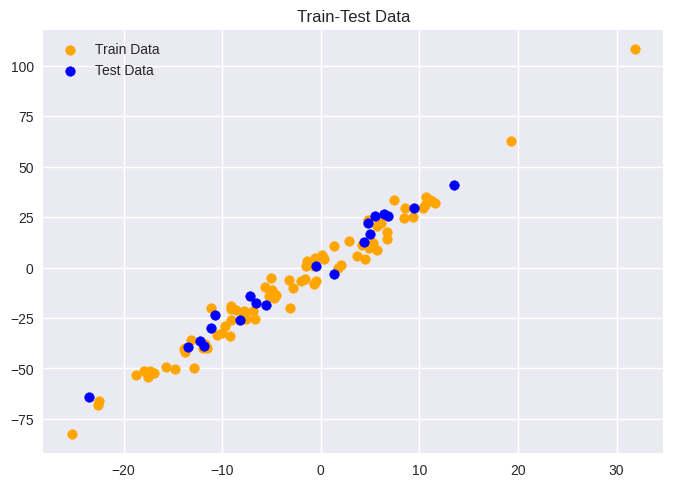

In [200]:
plt.scatter(XT, yT, color="orange", label="Train Data")
plt.scatter(Xt, yt, color="blue", label="Test Data")
plt.title("Train-Test Data")
plt.legend()
plt.show()

In [201]:
# Hypothesis
def hypothesis(X, theta):
  return theta[0] + theta[1] * X

In [202]:
# error
def error(X, y, theta):
  m = X.shape[0]
  e = 0
  for i in range(m):
    y_i = hypothesis(X[i], theta)
    e = e + (y[i] - y_i)**2

  return e/(2*m)

In [203]:
def gradient(X, y, theta):
  m = X.shape[0]
  grad = np.zeros((2,))

  for i in range(m):
    exp = hypothesis(X[i], theta) - y[i]
    grad[0] += exp
    grad[1] += exp * X[i]

  return grad/m

In [204]:
def train(X, y, learning_rate=0.001, maxItrs=100):
  theta = np.zeros((2,))
  error_list = []

  for i in range(maxItrs):
    grad = gradient(X, y, theta)
    error_list.append(error(X, y, theta))
    theta[0] = theta[0] - learning_rate * grad[0]
    theta[1] = theta[1] - learning_rate * grad[1]

  plt.xlabel("Iteration Number")
  plt.ylabel("Loss")
  plt.plot(error_list)
  plt.show()

  return theta

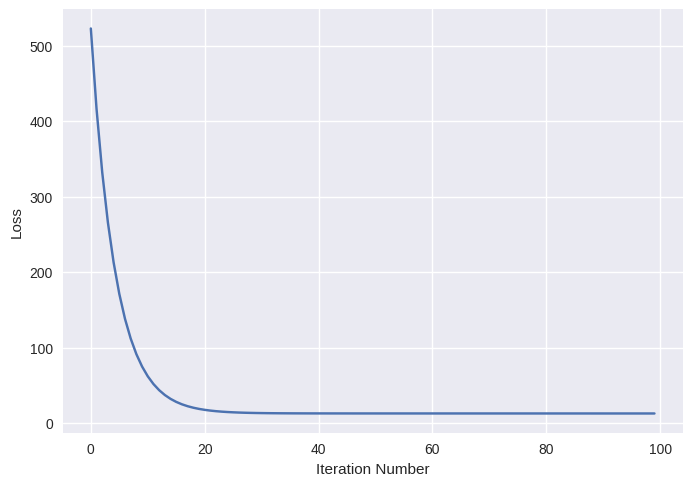

In [205]:
theta = train(X,y)

In [206]:
def predict(X, theta):
  return hypothesis(X, theta)

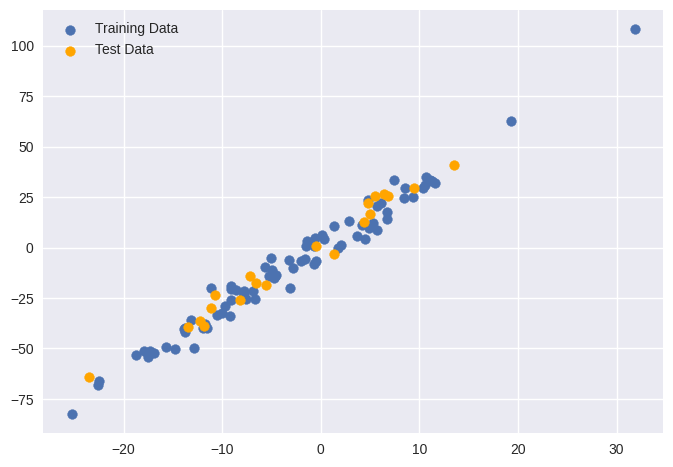

In [207]:
plt.scatter(XT, yT, label="Training Data")
plt.scatter(Xt, yt, color="orange", label="Test Data")
plt.legend()
plt.show()

In [208]:
yp = predict(Xt, theta)

In [209]:
print(Xt.shape)
print(yp.shape)

(20,)
(20,)


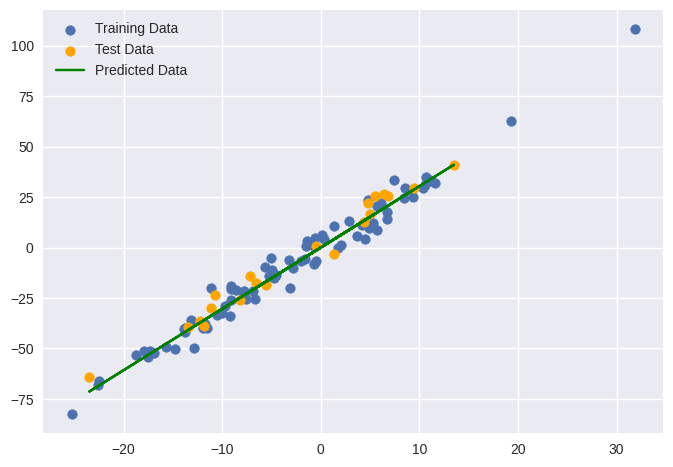

In [210]:
plt.scatter(XT, yT, label="Training Data")
plt.scatter(Xt, yt, color="orange", label="Test Data")
plt.plot(Xt, yp, color="green", label="Predicted Data")
plt.legend()
plt.show()

In [211]:
# Model evaluation
def r2Score(y, yp):
  ymean = np.mean(y)
  num = np.sum((y - yp)**2)
  denom = np.sum((y - ymean)**2)

  return 1 - num/denom

In [212]:
print(r2Score(yt, yp))

0.9694765758672778
